# Modeling the simulated lightcurves

The purpose of this notebook is to generate microlensing models for the simulated event lightcurves, using the simulation input parameters.

In [1]:
from os import path
import numpy as np
import matplotlib.pyplot as plt
import parse_table1
import load_sim_lc
from astropy import units as u
from pyLIMA import event
from pyLIMA import telescopes
from pyLIMA.models import PSPL_model, USBL_model
from pyLIMA.outputs import pyLIMA_plots
from pyLIMA.parallax import JPL_ephemerides
from pyLIMA import toolbox

In [2]:
# Set path to Data Challenge datafiles for simulated event lightcurves 
DATA_DIR = '/Users/rstreet/Roman/data-challenge-1/lc'

In [3]:
# Load the master file of the simulated event parameters 
master_file = '/Users/rstreet/Roman/data-challenge-1/Answers/master_file.txt'
master_data = parse_table1.read_master_table(master_file)
print('Loaded information for ' + str(len(master_data)) + ' lightcurves')

Loaded information for 293 lightcurves


In [16]:
master_data['ulwdc1_006'].summary()

" idx=6 modelID='ulwdc1_006' model_class='Binary_star' t0=2459651.8548187 sig_t0=0.0 tE=5.31401 sig_tE=0.0 u0=-0.00588459 sig_u0=0.0 rho=0.000772343 sig_rho=0.0 piE=0.0902075 sig_piE=0.0 piEE=None sig_piEE=None piEN=None sig_piEN=None fs_J=3.7061244615884745 sig_fs_J=0.0 fs_H=7.882064782498059 sig_fs_H=0.0 fs_W=5.0619750473102965 sig_fs_W=0.0 fs_Z=0.7646804727908197 sig_fs_Z=0.0 fb_Z=0.7297935152144471 sig_fb_Z=None fb_W=4.3347095239876685 sig_fb_W=0.0 fb_J=4.144574971253579 sig_fb_J=0.0 fb_H=6.213266760213593 sig_fb_H=None s=0.113947 sig_s=0.0 q=0.383817 sig_q=0.0 alpha=114.126 sig_alpha=0.0 dsdt=np.float64(-0.022074885795925814) sig_dsdt=None dadt=np.float64(-5.535840131533309) sig_dadt=None t0_par=None chisq_W=None chisq_Z=None M1=0.15 sig_M1=None M2=0.0575726 sig_M2=None DL=7.504 sig_DL=None DS=8.368 sig_DS=None aperp=0.139503 sig_aperp=None t_fit=0.0"

In [17]:
# Load the ephemeris data for the spacecraft, used to calculate the parallax
wephem = np.loadtxt(path.join(DATA_DIR, '..', 'wfirst_ephemeris_W149.txt'))
zephem = np.loadtxt(path.join(DATA_DIR, '..', 'wfirst_ephemeris_Z087.txt'))

Firstly, let's select an example of a simulated lightcurve to examine and load the lightcurve data.

In [18]:
eventID = 'ulwdc1_006'
model_type = 'USBL'   # One of PSPL, USBL

In [19]:
wlc_path = path.join(DATA_DIR, eventID + '_W149.txt')
zlc_path = path.join(DATA_DIR, eventID + '_Z087.txt')
wlc = load_sim_lc.load_lc(wlc_path)
zlc = load_sim_lc.load_lc(zlc_path)

Now we can extract the parameters of the model used to simulate this event's lightcurve from the master_file table.

In [20]:
sim_event_params = master_data[eventID]
print(sim_event_params.ra, sim_event_params.dec, sim_event_params.summary())

267.649 -28.2978  idx=6 modelID='ulwdc1_006' model_class='Binary_star' t0=2459651.8548187 sig_t0=0.0 tE=5.31401 sig_tE=0.0 u0=-0.00588459 sig_u0=0.0 rho=0.000772343 sig_rho=0.0 piE=0.0902075 sig_piE=0.0 piEE=None sig_piEE=None piEN=None sig_piEN=None fs_J=3.7061244615884745 sig_fs_J=0.0 fs_H=7.882064782498059 sig_fs_H=0.0 fs_W=5.0619750473102965 sig_fs_W=0.0 fs_Z=0.7646804727908197 sig_fs_Z=0.0 fb_Z=0.7297935152144471 sig_fb_Z=None fb_W=4.3347095239876685 sig_fb_W=0.0 fb_J=4.144574971253579 sig_fb_J=0.0 fb_H=6.213266760213593 sig_fb_H=None s=0.113947 sig_s=0.0 q=0.383817 sig_q=0.0 alpha=114.126 sig_alpha=0.0 dsdt=np.float64(-0.022074885795925814) sig_dsdt=None dadt=np.float64(-5.535840131533309) sig_dadt=None t0_par=None chisq_W=None chisq_Z=None M1=0.15 sig_M1=None M2=0.0575726 sig_M2=None DL=7.504 sig_DL=None DS=8.368 sig_DS=None aperp=0.139503 sig_aperp=None t_fit=0.0


We now use these parameters to generate a microlensing model. 

In [21]:
sim_event = event.Event(ra=sim_event_params.ra, dec=sim_event_params.dec)
sim_event.name = eventID

In [22]:
# Add the simulated lightcurves to the event.  
wtel = telescopes.Telescope(name = 'Roman_W149', 
                            camera_filter = 'W149',
                            lightcurve = wlc.as_array(),
                            lightcurve_names = ['time','mag','err_mag'],
                            lightcurve_units = ['JD','mag','mag'],
                           astrometry=None)
wtel.location = 'Space'
wtel.spacecraft_name = 'L2'

ztel = telescopes.Telescope(name = 'Roman_Z087', 
                            camera_filter = 'Z087',
                            lightcurve = wlc.as_array(),
                            lightcurve_names = ['time','mag','err_mag'],
                            lightcurve_units = ['JD','mag','mag'],
                           astrometry=None)
ztel.location = 'Space'
ztel.spacecraft_name = 'L2'

sim_event.telescopes.append(wtel)
sim_event.telescopes.append(ztel)

In [23]:
# Designate the most densely sampled lightcurve as the 'survey' reference 
sim_event.find_survey('Roman_W149')
sim_event.check_event()

check_event  : Everything looks fine...


In [24]:
# Chose the appropriate model for the event 
if model_type == 'PSPL':
    event_model = PSPL_model.PSPLmodel(sim_event, parallax=['Full', sim_event_params.t0], blend_flux_parameter='ftotal')
elif model_type == 'USBL':
    event_model = USBL_model.USBLmodel(sim_event, parallax=['Full', sim_event_params.t0], blend_flux_parameter='ftotal')
else:
    print('Error: Only PSPL or USBL models supported right now')
event_model.define_model_parameters()

Successfully ephemeris from JPL!
Parallax(Full) estimated for the telescope Roman_W149: SUCCESS
Successfully ephemeris from JPL!
Parallax(Full) estimated for the telescope Roman_Z087: SUCCESS


In [25]:
event_model.model_dictionnary

OrderedDict([('t0', 0),
             ('u0', 1),
             ('tE', 2),
             ('rho', 3),
             ('separation', 4),
             ('mass_ratio', 5),
             ('alpha', 6),
             ('piEN', 7),
             ('piEE', 8),
             ('fsource_Roman_W149', 9),
             ('ftotal_Roman_W149', 10),
             ('fsource_Roman_Z087', 11),
             ('ftotal_Roman_Z087', 12)])

In [26]:
# Set the model parameters to those of the simulation input 
# [t0,u0,tE,rho,s,q,alpha]
model_params = [
    sim_event_params.t0,
    sim_event_params.u0,
    sim_event_params.tE,
    sim_event_params.rho,
]
if model_type == 'USBL':
    model_params.append(sim_event_params.s)
    model_params.append(sim_event_params.q) 
    model_params.append(sim_event_params.alpha)

if sim_event_params.piEE:
    model_params.append(sim_event_params.piEE)
    model_params.append(sim_event_params.piEN)
else:
    model_params.append(0.0)
    model_params.append(0.0)

ftotal_W = sim_event_params.fs_W + sim_event_params.fb_W 
ftotal_Z = sim_event_params.fs_Z + sim_event_params.fb_Z
model_params.append(sim_event_params.fs_W)
model_params.append(ftotal_W)
model_params.append(sim_event_params.fs_Z)
model_params.append(ftotal_Z)

pyLIMA_parameters = event_model.compute_pyLIMA_parameters(model_params)
print(pyLIMA_parameters)

OrderedDict([('t0', 2459651.8548187), ('u0', -0.00588459), ('tE', 5.31401), ('rho', 0.000772343), ('separation', 0.113947), ('mass_ratio', 0.383817), ('alpha', 114.126), ('piEN', 0.0), ('piEE', 0.0), ('fsource_Roman_W149', 5.0619750473102965), ('ftotal_Roman_W149', 9.396684571297964), ('fsource_Roman_Z087', 0.7646804727908197), ('ftotal_Roman_Z087', 1.4944739880052669)])


In [27]:
# Calculate the model lightcurve using a simulated telescope object
model_telescope = pyLIMA_plots.create_telescopes_to_plot_model(event_model, pyLIMA_parameters)[0]

flux_model = event_model.compute_the_microlensing_model(model_telescope, pyLIMA_parameters)['photometry']

magnitude = toolbox.brightness_transformation.flux_to_magnitude(flux_model)

model_telescope.lightcurve["mag"] = magnitude * u.mag

mask = ~np.isnan(magnitude)
model_telescope.lightcurve = model_telescope.lightcurve[mask]

#model_telescope.lightcurve

Successfully ephemeris from JPL!
Parallax(Full) estimated for the telescope Roman_W149: SUCCESS
Successfully ephemeris from JPL!
Parallax(Full) estimated for the telescope Roman_Z087: SUCCESS


In [28]:
model_telescope.lightcurve

time,mag,err_mag,flux,err_flux,inv_err_flux
JD,mag,mag,W / m2,W / m2,m2 / W
float64,float64,float64,float64,float64,float64
2458346.505461,24.967563378076633,0.1,91201083935.59077,8399930253.399603,1.1904860752805442e-10
2458346.51,24.96756337807663,0.1,91201083935.59077,8399930253.399603,1.1904860752805442e-10
2458346.515987,24.967563378076623,0.1,91201083935.59077,8399930253.399603,1.1904860752805442e-10
2458346.526513,24.967563378076616,0.1,91201083935.59077,8399930253.399603,1.1904860752805442e-10
2458346.53704,24.96756337807661,0.1,91201083935.59077,8399930253.399603,1.1904860752805442e-10
2458346.547566,24.967563378076598,0.1,91201083935.59077,8399930253.399603,1.1904860752805442e-10
2458346.558093,24.96756337807659,0.1,91201083935.59077,8399930253.399603,1.1904860752805442e-10
2458346.568619,24.967563378076584,0.1,91201083935.59077,8399930253.399603,1.1904860752805442e-10


In [29]:
def plot_lc(wlc, zlc, inset_xmin, inset_xmax, plot_file, 
            inset_left=0.35, inset_bottom=0.3, inset_width=0.6, inset_height=0.6, xmin=None, xmax=None, 
           model_lc=None
           ):
    """
    Function to plot simulated Roman lightcurves, showing the full extent of the multi-season lightcurve plus 
    an inset box showing a zoom in lightcurve around the event peak. 

    Parameters:
        wlc  Table   Lightcurve data table for W146 filter 
        zlc  Table   Lightcurve data table for Z087 filter 
        inset_xmin float  Minimum x-range of the inset axis 
        inset_ymax float  Maximum x-range of the inset axis
        plot_file  str    File path for saved PNG plot
        inset_left float  [optional] Left-edge coordinate of inset box relative to the main axis [0-1] 
        inset_bottom float [optional] Bottom-edge coordinate of inset box 
        inset_width float [optional] Width of the inset box 
        inset_height float [optional] Height of the inset box
        xmin float [optional] Minimum timestamp for x axis 
        xmax float [optional] Maximum timestamp for x axis 
        model_lc  Table  [optional] Model lightcurve data table 
        
    Returns:
        None, output lightcurve saved to plot_file
    """
    PLOT_COLORS = {
    'W149': '#03A66A',
    'Z087': '#2E03A6'
    }
    
    fig, axs = plt.subplots(1, 1, figsize=(10,10))
    
    dt = 2450000.0
    
    axs.errorbar(wlc['JD']-dt, wlc['mag'], yerr=wlc['mag_err'], ms=20, ls='none', c=PLOT_COLORS['W149'], label='W149')
    axs.errorbar(wlc['JD']-dt, wlc['mag'], yerr=wlc['mag_err'], ms=20, ls='none', c=PLOT_COLORS['Z087'], label='Z087')
    
    axs.invert_yaxis()
    
    axs.set_xlabel('JD-2450000.0 [days]', fontsize=20) 
    axs.set_ylabel('Mag', fontsize=20)
    axs.set_title('Lightcurve for event ' + eventID, fontsize=20)
    axs.tick_params(axis='x', labelsize=18)
    axs.tick_params(axis='y', labelsize=18)
    
    axs.grid()
    axs.legend(fontsize=18)
    
    # Add inset axes; coordinates are 0-1 relative to main axis 
    #ax_inset = axs.inset_axes([inset_left, inset_bottom, inset_width, inset_height])
    
    #ax_inset.errorbar(wlc['JD']-dt, wlc['mag'], yerr=wlc['mag_err'], ls='none', c=PLOT_COLORS['W149'], label='W149')
    #ax_inset.errorbar(wlc['JD']-dt, wlc['mag'], yerr=wlc['mag_err'], ls='none', c=PLOT_COLORS['Z087'], label='Z087')
    
    #ax_inset.invert_yaxis()
    #ax_inset.set_xlim(inset_xmin, inset_xmax)
    #ax_inset.tick_params(axis='x', labelsize=16)
    #ax_inset.tick_params(axis='y', labelsize=16)
    
    axs.tick_params(axis='x', labelsize=18)
    axs.tick_params(axis='y', labelsize=18)

    if xmin:
        axs.set_xlim(xmin, xmax)
        
    #ax_inset.grid()

    if model_lc:
        axs.plot(model_lc['time'].value-dt, model_lc['mag'], c='black', ls='-', alpha=0.6)
        
    plt.tight_layout()
    
    plt.savefig(plot_file)

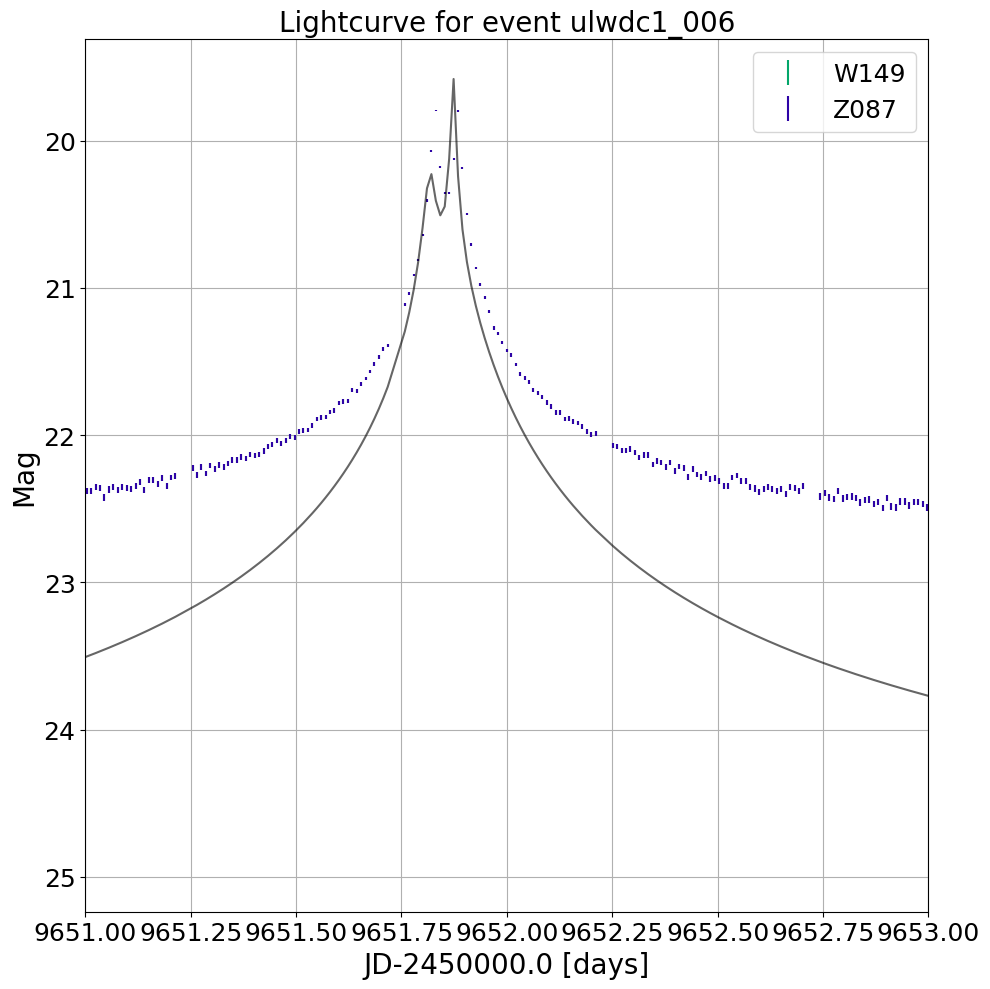

In [30]:
plot_file = path.join(DATA_DIR, eventID + '_model_lc.png')
plot_lc(wlc, zlc, 0.0, 0.0, plot_file, xmin=9651, xmax=9653, model_lc=model_telescope.lightcurve)